In [33]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [34]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [35]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-1.353636,-0.102564,-0.629496,-0.222210,-0.579431,0
1,1.068224,0.193348,-1.335610,0.217107,-0.069825,0
2,-0.702592,1.421581,-0.208027,-0.395592,0.202029,1
3,-2.297434,-1.841194,-1.915070,-2.103041,0.502353,0
4,-0.726558,0.777267,-0.910621,-1.016239,0.398323,1


In [36]:
# # function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [43]:
# function for feature sampling
import random
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols].copy()
  new_df['target'] = df['target']
  return new_df


In [44]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [45]:
df1 = combined_sampling(df,0.5,0.5)

In [46]:
df2 = combined_sampling(df,0.5,0.5)

In [47]:
df3 = combined_sampling(df,0.5,0.5)

In [48]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col2', 'col3', 'target'], dtype='object')
Index(['col1', 'col2', 'target'], dtype='object')
Index(['col4', 'col5', 'target'], dtype='object')


In [49]:
df3

,col4,col5,target
60,-1.256366,-0.758636,0
58,-0.209204,-0.020163,1
37,-0.666547,2.535794,0
31,0.831435,0.385541,0
32,1.685206,0.031382,0
79,-3.158505,3.413174,1
5,-3.212729,2.140575,0
11,-0.096229,0.516640,0
32,1.685206,0.031382,0
70,-0.904224,-0.598680,0


In [52]:
from sklearn.tree import DecisionTreeClassifier

clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [53]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf3.fit(df1.iloc[:,0:2],df1.iloc[:,-1])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [54]:
from sklearn.tree import plot_tree

[Text(0.4444444444444444, 0.9375, 'x[0] <= 1.182\ngini = 0.493\nsamples = 50\nvalue = [28.0, 22.0]'),
 Text(0.3333333333333333, 0.8125, 'x[0] <= -1.305\ngini = 0.346\nsamples = 36\nvalue = [28, 8]'),
 Text(0.38888888888888884, 0.875, 'True  '),
 Text(0.2222222222222222, 0.6875, 'gini = 0.0\nsamples = 14\nvalue = [14, 0]'),
 Text(0.4444444444444444, 0.6875, 'x[1] <= -2.309\ngini = 0.463\nsamples = 22\nvalue = [14, 8]'),
 Text(0.3333333333333333, 0.5625, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.5555555555555556, 0.5625, 'x[0] <= -0.019\ngini = 0.498\nsamples = 15\nvalue = [7, 8]'),
 Text(0.4444444444444444, 0.4375, 'x[1] <= -0.696\ngini = 0.42\nsamples = 10\nvalue = [7, 3]'),
 Text(0.2222222222222222, 0.3125, 'x[1] <= -1.43\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.1111111111111111, 0.1875, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3333333333333333, 0.1875, 'x[0] <= -0.675\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.2222222222222222, 0.0625, 'gini

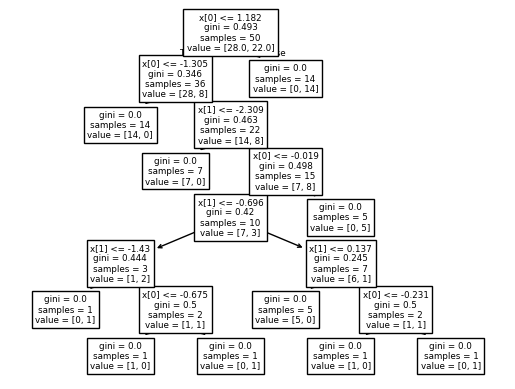

In [55]:
plot_tree(clf1)

[Text(0.4444444444444444, 0.9375, 'x[0] <= 1.182\ngini = 0.493\nsamples = 50\nvalue = [28.0, 22.0]'),
 Text(0.3333333333333333, 0.8125, 'x[0] <= -1.305\ngini = 0.346\nsamples = 36\nvalue = [28, 8]'),
 Text(0.38888888888888884, 0.875, 'True  '),
 Text(0.2222222222222222, 0.6875, 'gini = 0.0\nsamples = 14\nvalue = [14, 0]'),
 Text(0.4444444444444444, 0.6875, 'x[1] <= -2.309\ngini = 0.463\nsamples = 22\nvalue = [14, 8]'),
 Text(0.3333333333333333, 0.5625, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.5555555555555556, 0.5625, 'x[0] <= -0.019\ngini = 0.498\nsamples = 15\nvalue = [7, 8]'),
 Text(0.4444444444444444, 0.4375, 'x[1] <= -0.696\ngini = 0.42\nsamples = 10\nvalue = [7, 3]'),
 Text(0.2222222222222222, 0.3125, 'x[0] <= -0.983\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.1111111111111111, 0.1875, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3333333333333333, 0.1875, 'x[0] <= -0.675\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.2222222222222222, 0.0625, 'gin

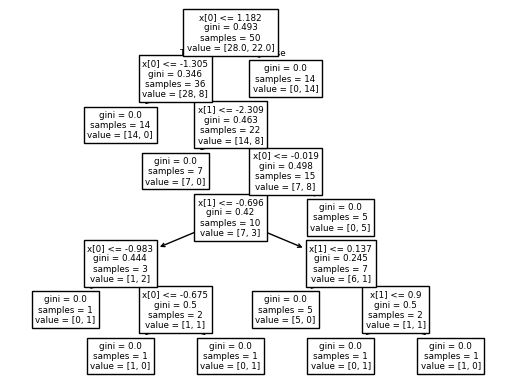

In [56]:
plot_tree(clf2)

[Text(0.4444444444444444, 0.9375, 'x[0] <= 1.182\ngini = 0.493\nsamples = 50\nvalue = [28.0, 22.0]'),
 Text(0.3333333333333333, 0.8125, 'x[0] <= -1.305\ngini = 0.346\nsamples = 36\nvalue = [28, 8]'),
 Text(0.38888888888888884, 0.875, 'True  '),
 Text(0.2222222222222222, 0.6875, 'gini = 0.0\nsamples = 14\nvalue = [14, 0]'),
 Text(0.4444444444444444, 0.6875, 'x[1] <= -2.309\ngini = 0.463\nsamples = 22\nvalue = [14, 8]'),
 Text(0.3333333333333333, 0.5625, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.5555555555555556, 0.5625, 'x[0] <= -0.019\ngini = 0.498\nsamples = 15\nvalue = [7, 8]'),
 Text(0.4444444444444444, 0.4375, 'x[1] <= -0.696\ngini = 0.42\nsamples = 10\nvalue = [7, 3]'),
 Text(0.2222222222222222, 0.3125, 'x[0] <= -0.983\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.1111111111111111, 0.1875, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3333333333333333, 0.1875, 'x[0] <= -0.675\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.2222222222222222, 0.0625, 'gin

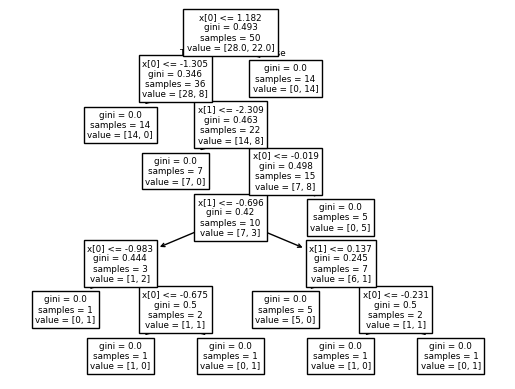

In [57]:
plot_tree(clf3)

In [58]:
clf1.predict(np.array([-1.042498,-0.064323]).reshape(1,2))

C:\Users\my5ee\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [59]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\my5ee\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [60]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\my5ee\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [61]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
83,0.202848,0.335748,-1.648256,-0.126457,-0.871149,0
38,1.727015,0.112627,-1.340305,0.843056,-0.325045,0
35,-2.535201,-0.603678,-0.763023,-0.613125,1.310409,1
60,-0.938886,0.547465,-1.971603,-1.256366,-0.758636,0
30,0.972981,2.955374,-0.904612,-0.812807,0.464582,1
85,-2.184955,-1.906625,-0.328017,-1.358320,1.867944,0
23,-1.800759,0.063654,-0.894582,-1.141784,0.969057,1
48,-0.501170,-0.310311,1.577953,0.314655,2.849999,0
4,-0.726558,0.777267,-0.910621,-1.016239,0.398323,1
65,2.258667,0.934908,-3.408085,-1.240762,-0.012428,0
